In [126]:
import pandas as pd
import numpy as np

def load_data(file_path: str)->pd.DataFrame:
    df = pd.read_csv(file_path)
    print(f"Dataframe shape: {df.shape}")
    print(f"Dataframe column types: {df.dtypes}")
    return df

df = load_data("data_midterm.csv")

Dataframe shape: (200, 7)
Dataframe column types: Depth (ft)                          float64
Porosity (%)                        float64
Matrix Perm (nd)                      int64
Acoustic impedance (kg/m2s*10^6)    float64
Brittleness Ratio                   float64
TOC (%)                              object
Vitrinite Reflectance (%)            object
dtype: object


# 1. Remove all samples with missing measurements and report the number of removed samples. 

In [127]:

def remove_nulls(df:pd.DataFrame)->pd.DataFrame:
    
    old_len = len(df)
    df = df.replace('na',np.nan).dropna()
    num_removed_nulls = old_len - len(df)
    print(f"Number of rows removed: {num_removed_nulls}")
    return df

df = remove_nulls(df)
df[['TOC (%)']] = df[['TOC (%)']].astype(np.float32)
df[['Vitrinite Reflectance (%)']] = df[['Vitrinite Reflectance (%)']].astype(np.float32)
df.dtypes

Number of rows removed: 9


Depth (ft)                          float64
Porosity (%)                        float64
Matrix Perm (nd)                      int64
Acoustic impedance (kg/m2s*10^6)    float64
Brittleness Ratio                   float64
TOC (%)                             float32
Vitrinite Reflectance (%)           float32
dtype: object

# 2. Check for duplicate entries and remove them if they are errors. Report the number of samples 
removed.

In [128]:

def remove_duplicates(df:pd.DataFrame)->pd.DataFrame:
    old_len = len(df)
    df = df.drop_duplicates()
    num_removed_duplicates = old_len - len(df)
    print(f"Number of rows removed: {num_removed_duplicates}")
    return df

df = remove_duplicates(df)

Number of rows removed: 0


# 3.  Identify  and  remove  samples  with  outlier  porosity  values.  Show  how  the  outliers  were determined and report the number of samples removed. 

PCA features shape: (191, 2)


<Axes: xlabel='[PCA_0]', ylabel='[PCA_1]'>

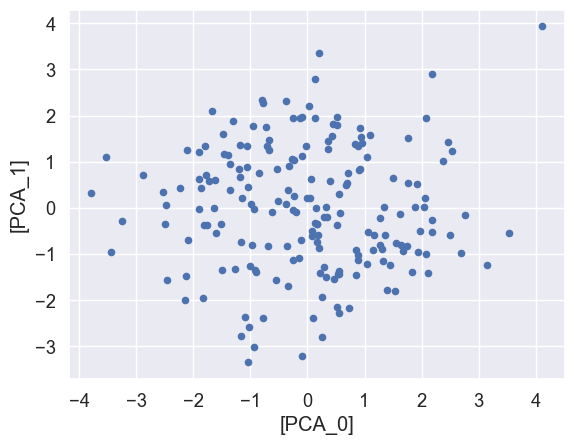

In [129]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# apply pca
def apply_pca(df:pd.DataFrame, n_components:int)->pd.DataFrame:

    scaler = StandardScaler()
    pca = PCA(n_components=n_components)
    pipeline = make_pipeline(scaler, pca)
    pipeline.fit(df)
    pca_features = pipeline.transform(df)
    pca_features_df = pd.DataFrame(pca_features)
    pca_features_df.columns = [f"PCA_{i}" for i in range(n_components)]
    print(f"PCA features shape: {pca_features_df.shape}")
    return pca_features_df

pca_features = apply_pca(df, 2)
pca_features.plot(kind='scatter', x=['PCA_0'], y=['PCA_1'])

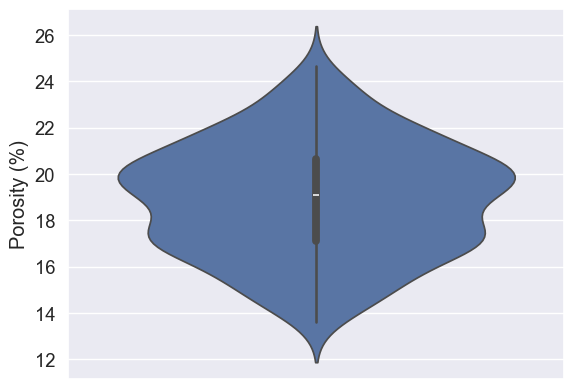

Number of rows removed: 4


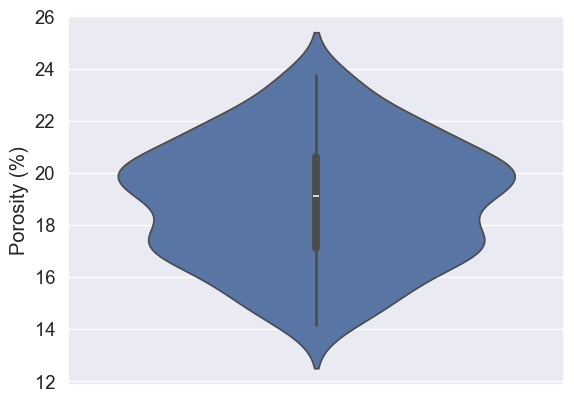

In [130]:

# z score outlier removal
def remove_outliers(df:pd.DataFrame, column_name:str, threshold:int=3)->pd.DataFrame:
    old_len = len(df)
    series = df[column_name]
    z_scores = (series - series.mean()) / series.std()
    abs_z_scores = np.abs(z_scores)
    filtered_entries = (abs_z_scores < threshold)
    df = df[filtered_entries]
    print(f"Number of rows removed: {old_len - len(df)}")
    return df

# violin plot
import seaborn as sns
import matplotlib.pyplot as plt
def plot_violin(df:pd.DataFrame, column_name:str):
    sns.violinplot(y=column_name, data=df)
    plt.show()


plot_violin(df, 'Porosity (%)')
df = remove_outliers(df, 'Porosity (%)', 2)
plot_violin(df, 'Porosity (%)')

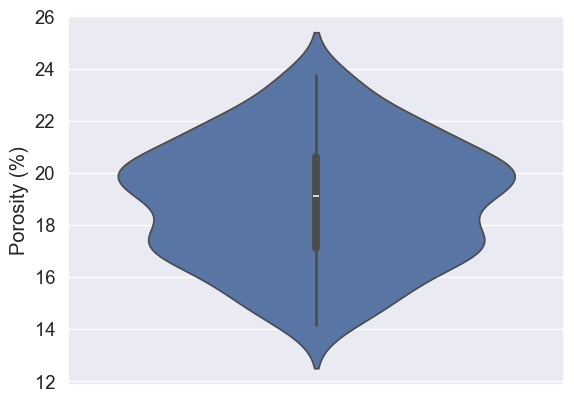

Number of rows removed: 63


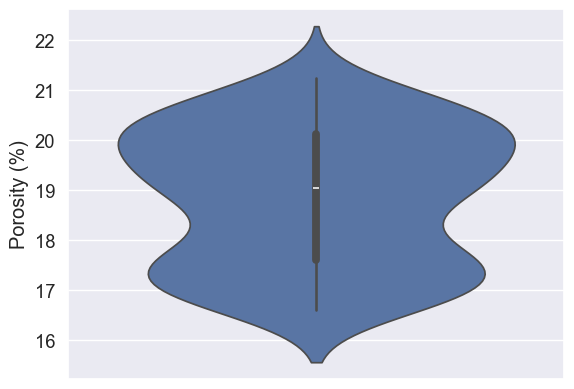

In [131]:
plot_violin(df, 'Porosity (%)')
df = remove_outliers(df, 'Porosity (%)', 1)
plot_violin(df, 'Porosity (%)')

# 4. Present the cross plots and histograms of all the cleaned properties.

/var/folders/zx/f36xk5q140n6m_949lbqqcx40000gn/T/ipykernel_95455/4251381985.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


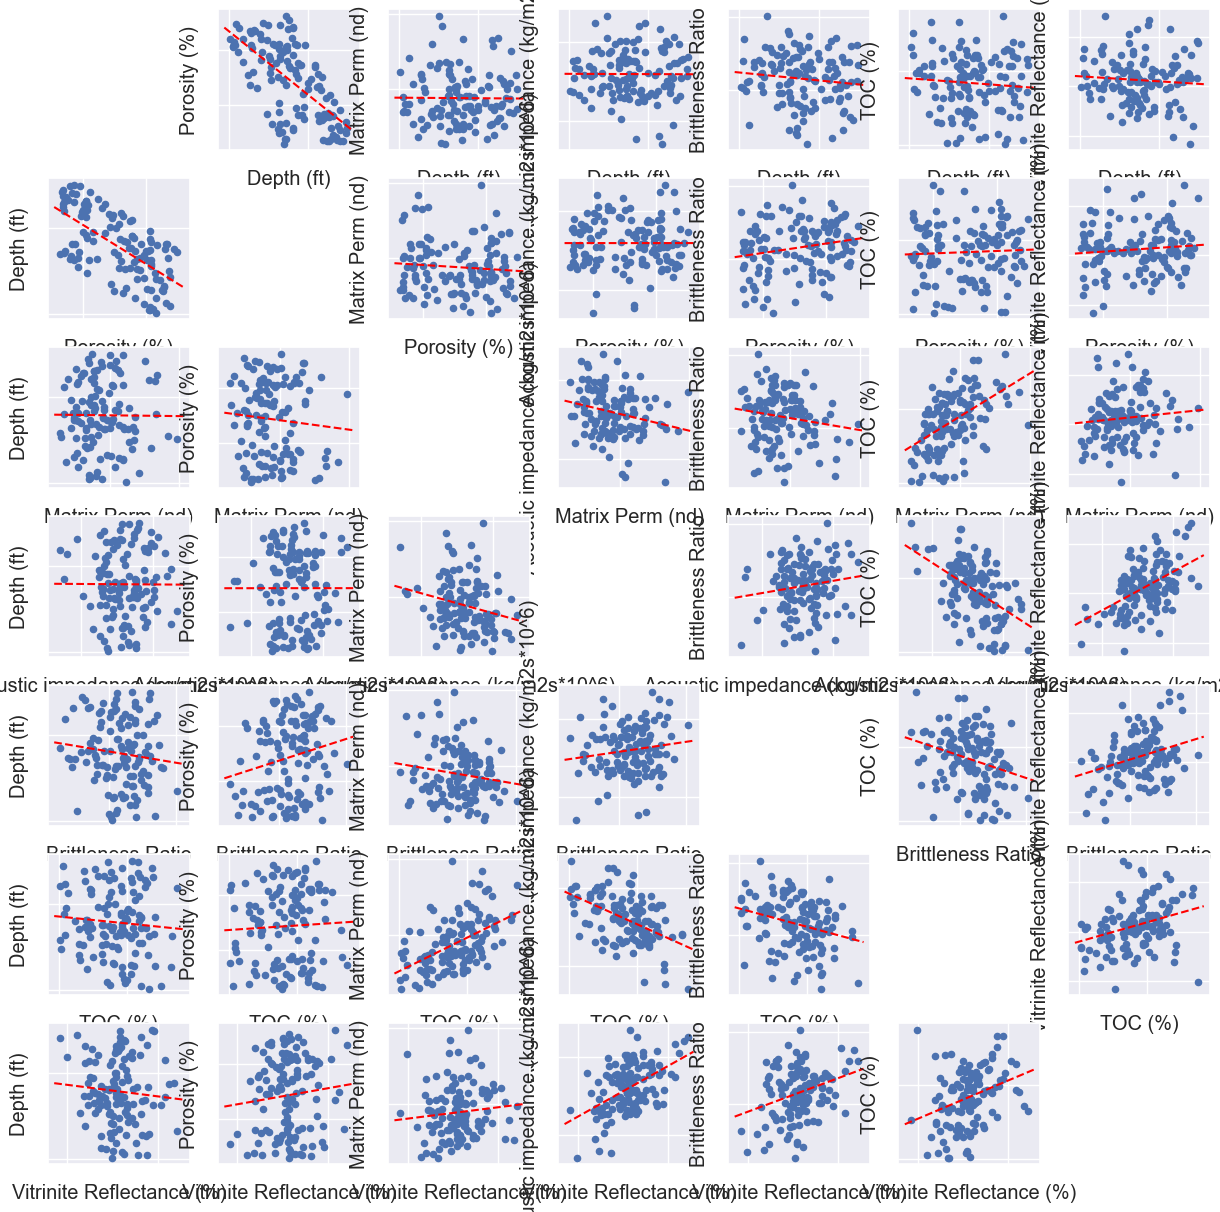

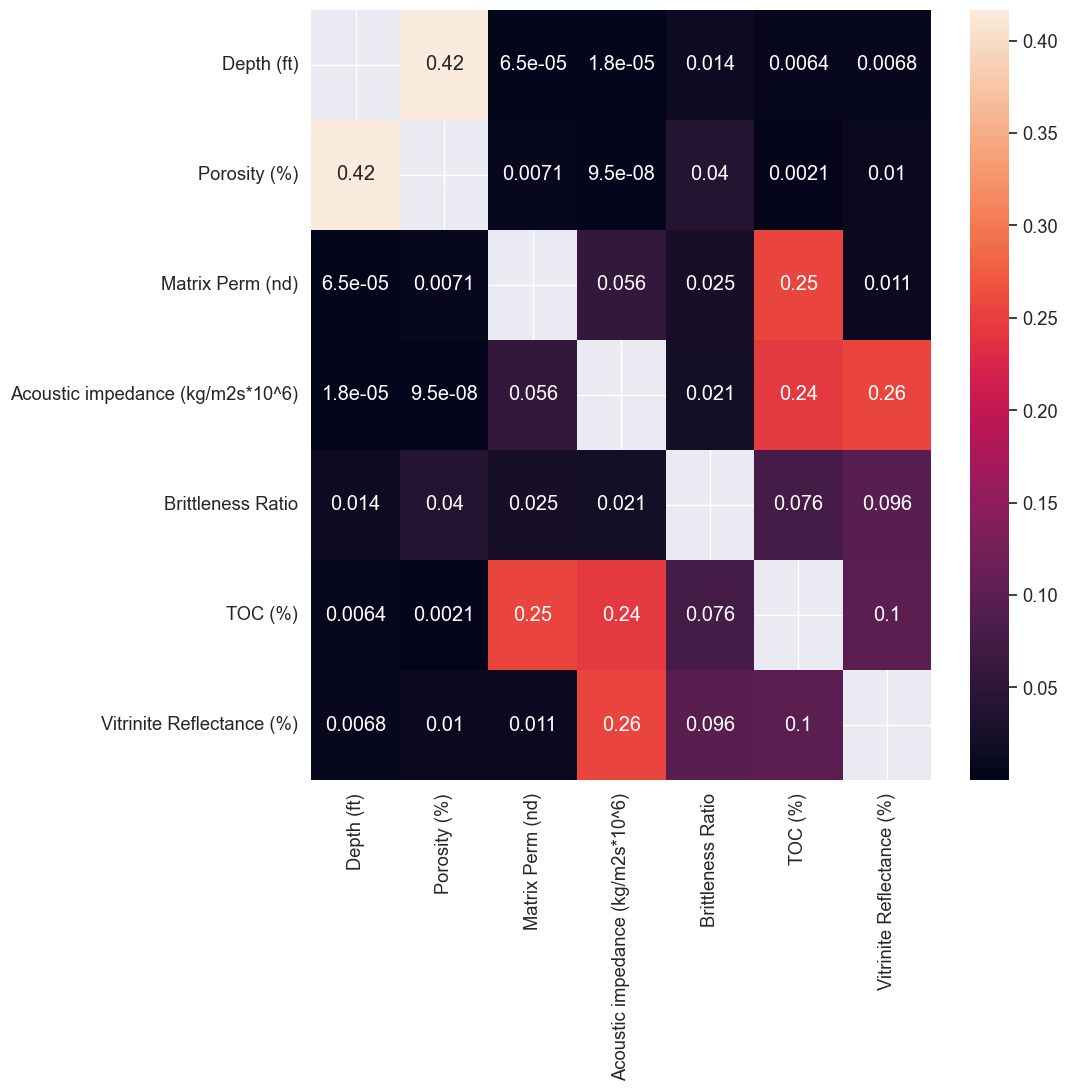

In [132]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# cross plots with regression lines and R^2 matrix calculation
def plot_cross(df: pd.DataFrame):
    num_cols = len(df.columns)
    r2_matrix = np.empty((num_cols, num_cols))
    r2_matrix[:] = np.nan  # fill non-applicable cells (diagonals)
    
    fig, axs = plt.subplots(num_cols, num_cols)
    for i in range(num_cols):
        for j in range(num_cols):
            if i != j:
                # create scatter plot
                ax = axs[i][j]
                df.plot(kind='scatter',
                        x=df.columns[i], y=df.columns[j], ax=ax, legend=False)

                # fit linear regression: slope & intercept
                x = df[df.columns[i]]
                y = df[df.columns[j]]
                slope, intercept = np.polyfit(x, y, 1)

                # get current x-axis limits to plot regression line across the entire range
                x_vals = np.array(ax.get_xlim())
                y_vals = intercept + slope * x_vals
                ax.plot(x_vals, y_vals, '--', color='red')

                # calculate predicted values and R^2
                y_pred = intercept + slope * x
                ss_res = np.sum((y - y_pred)**2)
                ss_tot = np.sum((y - y.mean())**2)
                r2 = 1 - (ss_res/ss_tot) if ss_tot != 0 else np.nan
                r2_matrix[i, j] = r2

            else:
                # remove duplicate plots along the diagonal
                axs[i][j].axis('off')

    # remove axis tick labels for clarity
    for ax in axs.flat:
        ax.set_xticklabels([])
        ax.set_yticklabels([])
    fig.set_size_inches(15, 15)
    fig.show()
    
    return r2_matrix


# Assuming df is defined earlier
r2_matrix = plot_cross(df)
# use seaborn heatmap to visualize R^2 matrix
def plot_r2_heatmap(r2_matrix: np.ndarray, columns: pd.Index):
    plt.figure(figsize=(10, 10))
    sns.set(font_scale=1.2)
    sns.heatmap(r2_matrix, annot=True, xticklabels=columns, yticklabels=columns)
    plt.show()

    
plot_r2_heatmap(r2_matrix, df.columns)
df.to_csv("cleaned_data.csv", index=False)

# 5. Determine all the correlation coefficients. 

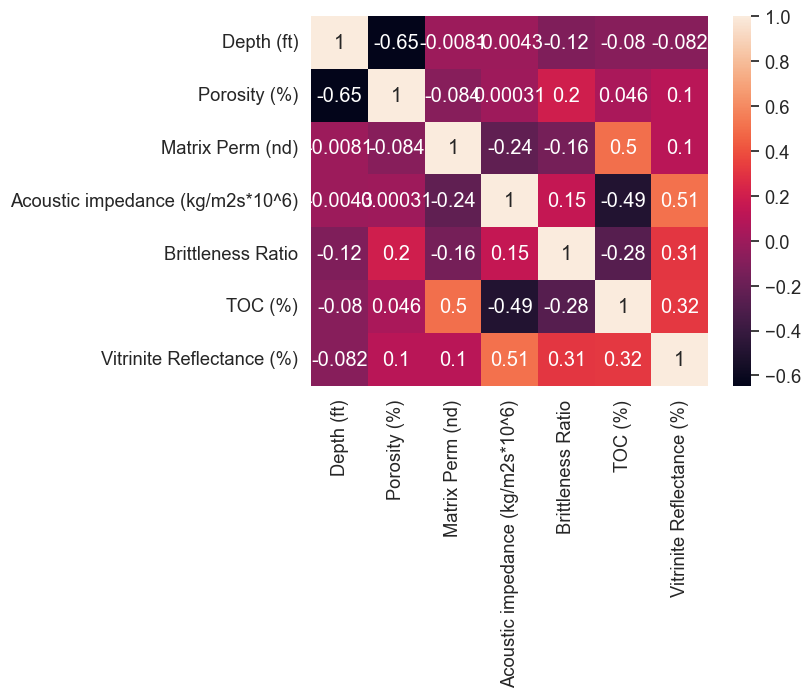

                                  Depth (ft)  Porosity (%)  Matrix Perm (nd)  \
Depth (ft)                          1.000000     -0.645596         -0.008051   
Porosity (%)                       -0.645596      1.000000         -0.084308   
Matrix Perm (nd)                   -0.008051     -0.084308          1.000000   
Acoustic impedance (kg/m2s*10^6)   -0.004299      0.000308         -0.237230   
Brittleness Ratio                  -0.118429      0.200922         -0.156596   
TOC (%)                            -0.080196      0.045889          0.504363   
Vitrinite Reflectance (%)          -0.082282      0.100563          0.104981   

                                  Acoustic impedance (kg/m2s*10^6)  \
Depth (ft)                                               -0.004299   
Porosity (%)                                              0.000308   
Matrix Perm (nd)                                         -0.237230   
Acoustic impedance (kg/m2s*10^6)                          1.000000   
Brittlene

In [133]:

# determine and plot all the correlation coefficients
def get_correlation_matrix(df:pd.DataFrame)->pd.DataFrame:
    corr = df.corr()
    sns.heatmap(corr, annot=True)
    plt.show()
    return corr

corr = get_correlation_matrix(df)
print(corr)

# 6. Discuss whether the correlation coefficients capture the dependency in this dataset.

# 7. Use a regression method of your choice to determine porosity as a function of depth. Report R2 and MSE.

In [145]:
import pprint
# pretty print the tuning parameters
pprint.print(
   
)
pprint(
    {
        'linear': {},  # No tuning parameters for OLS
        'ridge': {'model__alpha': [0.1, 1.0, 10.0]},
        'lasso': {'model__alpha': [0.001, 0.01, 0.1, 1.0]},
        'elastic': {'model__alpha': [0.001, 0.01, 0.1, 1.0],
                    'model__l1_ratio': [0.1, 0.5, 0.9]},
        'Random Forest': {'model__n_estimators': [50, 100, 200],
                          'model__max_depth': [None, 5, 10]},
        'Gradient Boosting': {'model__n_estimators': [50, 100, 200],
                              'model__learning_rate': [0.01, 0.1, 0.2]},
        'Support Vector Regressor': {'model__C': [0.1, 1.0, 10.0],
                                     'model__gamma': ['scale', 'auto']}
    }
)
 

AttributeError: module 'pprint' has no attribute 'print'

In [143]:
import yaml

with open("param_grids.yml", "r") as f:
    param_grids = yaml.safe_load(f)

print(param_grids)  # now you can pass this dict to train_pipelines() function

{'linear': {}, 'ridge': {'model__alpha': [0.1, 1.0, 10.0]}, 'lasso': {'model__alpha': [0.001, 0.01, 0.1, 1.0]}, 'elastic': {'model__alpha': [0.001, 0.01, 0.1, 1.0], 'model__l1_ratio': [0.1, 0.5, 0.9]}, 'Random Forest': {'model__n_estimators': [50, 100, 200], 'model__max_depth': [None, 5, 10]}, 'Gradient Boosting': {'model__n_estimators': [50, 100, 200], 'model__learning_rate': [0.01, 0.1, 0.2]}, 'Support Vector Regressor': {'model__C': [0.1, 1.0, 10.0], 'model__gamma': ['scale', 'auto']}}


In [ ]:
import yaml
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV
import numpy as np
import pandas as pd

# holds a registry of different regression models
class RegressionFactory:
    def __init__(self):
        self.models = {
            'linear': LinearRegression(),
            'ridge': Ridge(),
            'lasso': Lasso(),
            'elastic': ElasticNet(),
            'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
            'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
            'Support Vector Regressor': SVR()
        }
        self.metrics = {}
    def register(self, name, model):
        self.models[name] = model
    def get(self, name):
        return self.models.get(name)
    def register_metrics(self, name, metrics):
        self.metrics[name] = metrics

# PipelineFactory that builds a pipeline with scaling and modeling.
class PipelineFactory:
    def __init__(self):
        self.pipelines = {}  # registry for pipelines
    def create_pipeline(self, model):
        """Creates a pipeline with scaling and the given model."""
        return Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
    def register(self, name, pipeline):
        self.pipelines[name] = pipeline
    def get(self, name):
        return self.pipelines.get(name)

def split_data(df: pd.DataFrame, target: str, features: list, **kwargs) -> dict:
    train, test = train_test_split(df, **kwargs)
    if features is None:
        features = df.drop(target, axis=1).columns.tolist()
    train_X = train[features]
    train_y = train[target]
    test_X = test[features]
    test_y = test[target]
    return {'train_X': train_X, 'train_y': train_y, 'test_X': test_X, 'test_y': test_y}

def train_pipelines(df: pd.DataFrame, target: str, features: list, model_names: list,
                    model_factory: RegressionFactory, pipeline_factory: PipelineFactory,
                    param_grids: dict = {}):
    dataset = split_data(df, target, features, test_size=0.2, random_state=42)
    for model_name in model_names:
        model = model_factory.get(model_name)
        pipeline = pipeline_factory.create_pipeline(model)
        grid_params = param_grids.get(model_name, {})
        if grid_params:
            gs = GridSearchCV(pipeline, grid_params, cv=5)
            gs.fit(dataset['train_X'], dataset['train_y'])
            pipeline = gs.best_estimator_
            print(f"{model_name} pipeline tuned successfully, best parameters: {gs.best_params_}")
        else:
            pipeline.fit(dataset['train_X'], dataset['train_y'])
            print(f"{model_name} pipeline trained successfully (no tuning parameters)")
        # Evaluate model performance
        y_pred = pipeline.predict(dataset['test_X'])
        r2 = pipeline.score(dataset['test_X'], dataset['test_y'])
        mse = np.mean((y_pred - dataset['test_y'])**2)
        # Register pipeline and metrics
        pipeline_factory.register(model_name, pipeline)
        model_factory.register_metrics(model_name, {'r2': r2, 'mse': mse})



## no tuning

In [ ]:

param_grids = {}

# Instantiate factories and train pipelines with tuning functionality
model_factory = RegressionFactory()
pipeline_factory = PipelineFactory()
target = 'Porosity (%)'
features = ['Depth (ft)']
models = ['linear', 'ridge', 'lasso', 'elastic', 'Random Forest',
          'Gradient Boosting', 'Support Vector Regressor']

train_pipelines(df, target, features, models, model_factory,
                pipeline_factory, param_grids)

# Visualize the metrics with a bar plot
metrics_df = pd.DataFrame(model_factory.metrics)
metrics_df.plot(kind='bar')
metrics_df

## tuning

In [ ]:

with open("param_grids.yml", "r") as f:
    param_grids = yaml.safe_load(f)

# Instantiate factories and train pipelines with tuning functionality
model_factory = RegressionFactory()
pipeline_factory = PipelineFactory()
target = 'Porosity (%)'
features = ['Depth (ft)']
models = ['linear', 'ridge', 'lasso', 'elastic', 'Random Forest',
          'Gradient Boosting', 'Support Vector Regressor']

train_pipelines(df, target, features, models, model_factory,
                pipeline_factory, param_grids)

# Visualize the metrics with a bar plot
metrics_df = pd.DataFrame(model_factory.metrics)
metrics_df.plot(kind='bar')
metrics_df

linear model trained successfully
ridge model tuned successfully with best parameters: {'alpha': 10.0}
lasso model tuned successfully with best parameters: {'alpha': 0.001}
elastic model tuned successfully with best parameters: {'alpha': 0.001, 'l1_ratio': 0.1}
       linear     ridge     lasso   elastic
r2   0.554191  0.554196  0.554195  0.554191
mse  0.749088  0.749080  0.749080  0.749087


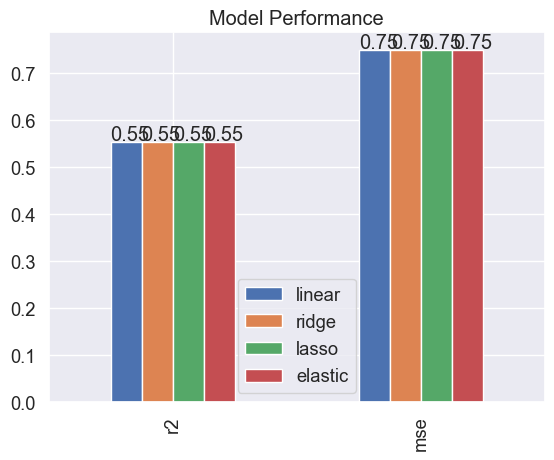

In [135]:
from sklearn.model_selection import  GridSearchCV



# Parameter grids for tuning each model
param_grids = {
    'linear': {},  # usually no hyperparameters to tune for OLS
    'ridge': {'alpha': [0.1, 1.0, 10.0]},
    'lasso': {'alpha': [0.001, 0.01, 0.1, 1.0]},
    'elastic': {'alpha': [0.001, 0.01, 0.1, 1.0],
                'l1_ratio': [0.1, 0.5, 0.9]}
}


def evaluate_tuned_models(df: pd.DataFrame, target: str, features: list, model_names: list, model_factory: RegressionFactory):
    dataset = split_data(df, target, features, test_size=0.2, random_state=42)
    

    for model_name in model_names:
        model = model_factory.get(model_name)
        params = param_grids.get(model_name, {})
        if params:
            # perform grid search if there are hyperparameters to tune
            gs = GridSearchCV(model, params, cv=5)
            gs.fit(dataset['train_X'], dataset['train_y'])
            model = gs.best_estimator_
            print(f"{model_name} model tuned successfully with best parameters: {gs.best_params_}")
        else:
            model.fit(dataset['train_X'], dataset['train_y'])
            print(f"{model_name} model trained successfully")
        
        # calculate metrics on test set
        y_pred = model.predict(dataset['test_X'])
        r2 = model.score(dataset['test_X'], dataset['test_y'])
        mse = np.mean((y_pred - dataset['test_y'])**2)
        
        # store metrics
        model_factory.register_metrics(model_name, {'r2': r2, 'mse': mse})
        # Optionally update the model in the factory with the tuned one
        model_factory.register(model_name, model)


model_factory = RegressionFactory()
target = 'Porosity (%)'
features = ['Depth (ft)', 'Brittleness Ratio']
models = ['linear', 'ridge', 'lasso', 'elastic']

evaluate_tuned_models(df, target, features, models, model_factory)
metrics_df = pd.DataFrame(model_factory.metrics)
print(metrics_df)
metrics_df.plot(kind='bar', title='Model Performance')
# add pandas df bar data labels
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() * 1.005, p.get_height() * 1.005))
plt.show()

# 8.  Determine  if  porosity  shows  a  stronger  dependency  on  any  other  property  than  indicated  in  problem 7. If so, develop an alternative regression model and report its R² and MSE values.